 # 1. Installation and Import

In [ ]:
!pip install transformers torch pandas openpyxl

import pandas as pd
from transformers import pipeline

# Load data
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('Banjir_ALL.xlsx')
print(df.shape)
print(df.columns.tolist())
print(df.head(2))

Saving Banjir_ALL.xlsx to Banjir_ALL.xlsx
(250, 4)
['Headline', 'Date', 'Link', 'Content']
                                            Headline               Date  \
0  Genangan Banjir Jakarta Bertambah Jadi di 3 RT...  31 Des 2023 19:41   
1  Jalan Jembatan Otista Bogor Banjir, Bima Arya ...  30 Des 2023 21:25   

                                                Link  \
0  https://news.detik.com/berita/d-7118033/genang...   
1  https://news.detik.com/berita/d-7116894/jalan-...   

                                             Content  
0  Jumlah titik genangan di wilayah Jakarta Selat...  
1  Jalan Jembatan Otista, Kota Bogor, sempat tere...  


# 2. Load IndoBERT NER Model

In [ ]:
# Load model IndoBERT NER
ner_pipeline = pipeline(
    "ner",
    model="cahya/bert-base-indonesian-NER",
    aggregation_strategy="simple"
)

print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded!


 # 3. Entity Extraction

In [ ]:
def extract_entities(text, max_length=512):
    if pd.isnull(text) or text == "":
        return []
    # Potong teks maksimal 512 karakter karena limit BERT
    text = str(text)[:max_length]
    try:
        entities = ner_pipeline(text)
        return entities
    except:
        return []

# Jalankan NER pada kolom Content
print("Sedang mengekstrak entitas dari 250 artikel...")
df['entities'] = df['Content'].apply(extract_entities)
print("Selesai!")
print(df['entities'][0])

Sedang mengekstrak entitas dari 250 artikel...
Selesai!
[{'entity_group': 'GPE', 'score': np.float32(0.95868796), 'word': 'jakarta selatan', 'start': 33, 'end': 48}, {'entity_group': 'NOR', 'score': np.float32(0.7985476), 'word': 'badan penanggulangan bencana daerah ( bpbd ) dki jakarta', 'start': 60, 'end': 114}, {'entity_group': 'CRD', 'score': np.float32(0.5134464), 'word': '3', 'start': 133, 'end': 134}, {'entity_group': 'NOR', 'score': np.float32(0.6584805), 'word': 'pusdatin kebencanaan bpbd dki jakarta', 'start': 199, 'end': 236}, {'entity_group': 'DAT', 'score': np.float32(0.99420625), 'word': '31 desember 2023', 'start': 242, 'end': 258}, {'entity_group': 'TIM', 'score': np.float32(0.99199396), 'word': '19. 00 wib', 'start': 265, 'end': 274}, {'entity_group': 'GPE', 'score': np.float32(0.91981447), 'word': 'dki jakarta', 'start': 340, 'end': 351}, {'entity_group': 'DAT', 'score': np.float32(0.99266505), 'word': 'minggu ( 31 / 12 )', 'start': 372, 'end': 386}, {'entity_group': 

 # 4. Flood-Specific Entity Extraction (Rule-Based)

In [ ]:
import re

def extract_custom_entities(text):
    if pd.isnull(text) or text == "":
        return []

    text_lower = str(text).lower()
    custom_entities = []

    # 1. TINGGI_AIR — angka + satuan
    tinggi_pattern = re.finditer(
        r'\b(\d+[\.,]?\d*)\s*(cm|centimeter|meter|m)\b',
        text_lower
    )
    for match in tinggi_pattern:
        custom_entities.append({
            'entity_group': 'TINGGI_AIR',
            'word': match.group(),
            'start': match.start(),
            'end': match.end()
        })

    # 2. JENIS_BANJIR — keyword
    jenis_keywords = [
        'banjir bandang', 'banjir rob', 'banjir lintasan',
        'banjir kiriman', 'banjir luapan', 'banjir genangan'
    ]
    for keyword in jenis_keywords:
        for match in re.finditer(keyword, text_lower):
            custom_entities.append({
                'entity_group': 'JENIS_BANJIR',
                'word': match.group(),
                'start': match.start(),
                'end': match.end()
            })

    # 3. KORBAN — angka + kata korban
    korban_pattern = re.finditer(
        r'\b(\d+)\s*(orang|jiwa|warga|korban|tewas|meninggal|hilang|luka)\b',
        text_lower
    )
    for match in korban_pattern:
        custom_entities.append({
            'entity_group': 'KORBAN',
            'word': match.group(),
            'start': match.start(),
            'end': match.end()
        })

    # 4. PENYEBAB
    penyebab_keywords = [
        'luapan sungai', 'luapan kali', 'tanggul jebol', 'tanggul bocor',
        'drainase tersumbat', 'drainase tidak memadai', 'gorong-gorong tersumbat',
        'curah hujan tinggi', 'intensitas hujan tinggi', 'hujan deras',
        'kiriman air', 'air kiriman', 'debit air meningkat'
    ]
    for keyword in penyebab_keywords:
        for match in re.finditer(keyword, text_lower):
            custom_entities.append({
                'entity_group': 'PENYEBAB',
                'word': match.group(),
                'start': match.start(),
                'end': match.end()
            })

    return custom_entities

# Test pada artikel pertama
print(extract_custom_entities(df['Content'][0]))

[{'entity_group': 'TINGGI_AIR', 'word': '30 cm', 'start': 894, 'end': 899}, {'entity_group': 'TINGGI_AIR', 'word': '60 cm', 'start': 1063, 'end': 1068}, {'entity_group': 'PENYEBAB', 'word': 'luapan kali', 'start': 1099, 'end': 1110}, {'entity_group': 'PENYEBAB', 'word': 'curah hujan tinggi', 'start': 921, 'end': 939}, {'entity_group': 'PENYEBAB', 'word': 'curah hujan tinggi', 'start': 1079, 'end': 1097}]


# 5. Combine Entities

In [ ]:
# Gabungkan semua entitas
df['custom_entities'] = df['Content'].apply(extract_custom_entities)

def combine_entities(row):
    all_entities = row['entities'] + row['custom_entities']
    return all_entities

df['all_entities'] = df.apply(combine_entities, axis=1)

# Tampilkan contoh artikel pertama dalam tabel
sample = df['all_entities'][0]
entity_df = pd.DataFrame(sample)[['entity_group', 'word', 'start', 'end']]
entity_df = entity_df.sort_values('start').reset_index(drop=True)

print(f"Artikel: {df['Headline'][0]}")
print(f"Tanggal: {df['Date'][0]}")
print()
print(entity_df.to_string(index=False))

Artikel: Genangan Banjir Jakarta Bertambah Jadi di 3 RT, Tinggi Air Capai 60 Cm
Tanggal: 31 Des 2023 19:41

entity_group                                                     word  start  end
         GPE                                          jakarta selatan     33   48
         NOR badan penanggulangan bencana daerah ( bpbd ) dki jakarta     60  114
         CRD                                                        3    133  134
         NOR                    pusdatin kebencanaan bpbd dki jakarta    199  236
         DAT                                         31 desember 2023    242  258
         TIM                                               19. 00 wib    265  274
         GPE                                              dki jakarta    340  351
         DAT                                       minggu ( 31 / 12 )    372  386
         ORG                                 pos pesanggrahan siaga 3    416  440
         TIM                                              17 : 00 wib   

# 6. Distribution Analysis

In [ ]:
from collections import Counter

# Hitung semua entitas dari semua artikel
all_entity_types = []
for entities in df['all_entities']:
    for ent in entities:
        all_entity_types.append(ent['entity_group'])

# Tampilkan distribusi
counter = Counter(all_entity_types)
dist_df = pd.DataFrame(counter.items(), columns=['Entity Type', 'Count'])
dist_df = dist_df.sort_values('Count', ascending=False).reset_index(drop=True)
print(dist_df.to_string(index=False))

 Entity Type  Count
         GPE    993
         LOC    395
         DAT    379
    PENYEBAB    349
  TINGGI_AIR    347
         CRD    300
         NOR    280
         QTY    260
         PER    230
         ORG    125
      KORBAN    112
JENIS_BANJIR     83
         TIM     79
         PRD     52
         EVT     41
         FAC     13
         ORD     13
         PRC      8
         LAW      4


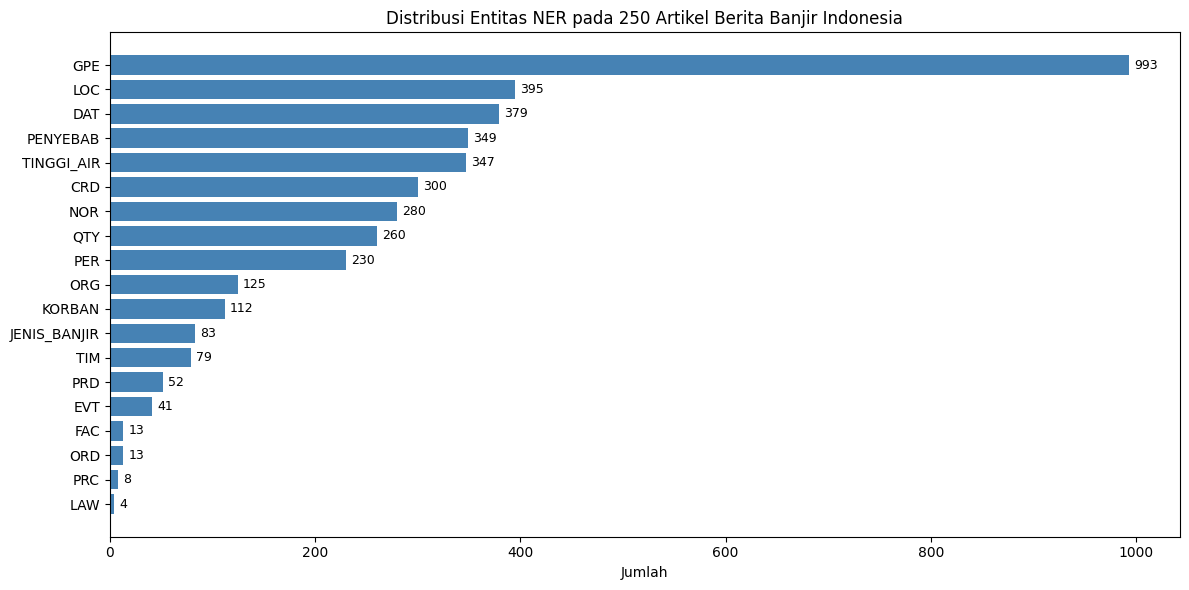

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.barh(dist_df['Entity Type'], dist_df['Count'], color='steelblue')

# Angka di ujung bar
for bar, val in zip(bars, dist_df['Count']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.title('Distribusi Entitas NER pada 250 Artikel Berita Banjir Indonesia')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

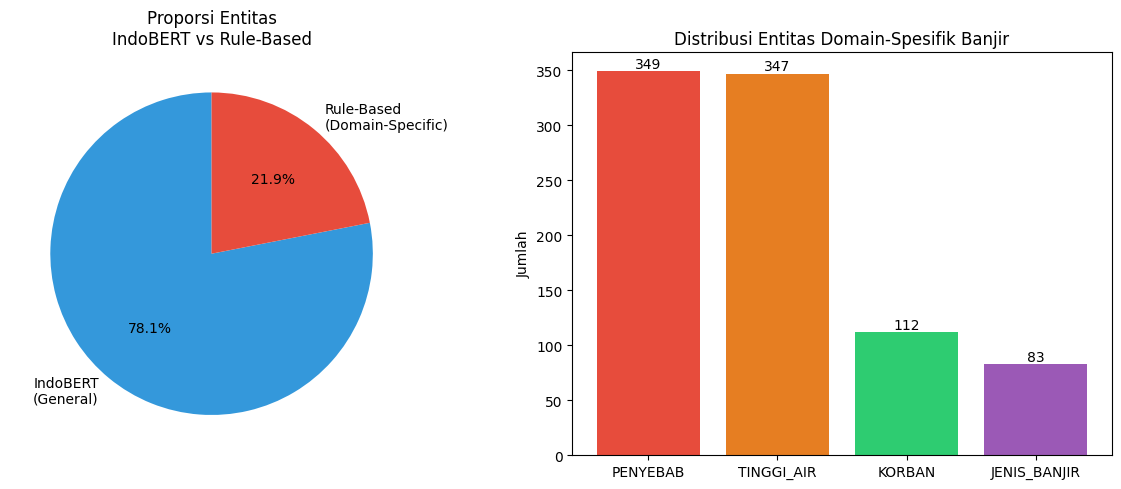

In [ ]:
# Pisahkan entitas IndoBERT vs custom
indobert_types = ['GPE', 'LOC', 'DAT', 'NOR', 'CRD', 'QTY', 'PER', 'ORG', 'TIM', 'PRD', 'EVT', 'FAC', 'ORD', 'PRC', 'LAW']
custom_types = ['TINGGI_AIR', 'JENIS_BANJIR', 'KORBAN', 'PENYEBAB']

indobert_count = sum([counter[t] for t in indobert_types])
custom_count = sum([counter[t] for t in custom_types])

# Pie chart perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    [indobert_count, custom_count],
    labels=['IndoBERT\n(General)', 'Rule-Based\n(Domain-Specific)'],
    colors=['#3498db', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Proporsi Entitas\nIndoBERT vs Rule-Based')

# Bar chart entitas custom saja
custom_df = dist_df[dist_df['Entity Type'].isin(custom_types)]
axes[1].bar(custom_df['Entity Type'], custom_df['Count'],
            color=['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6'])
for i, (_, row) in enumerate(custom_df.iterrows()):
    axes[1].text(i, row['Count'] + 3, str(row['Count']), ha='center')
axes[1].set_title('Distribusi Entitas Domain-Spesifik Banjir')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

# 7. Sample Results

In [ ]:
# Tampilkan ringkasan entitas untuk 5 artikel teratas
print("=== CONTOH HASIL EKSTRAKSI ENTITAS ===\n")

for i in range(5):
    entities = df['all_entities'][i]

    # Kelompokkan per tipe
    grouped = {}
    for ent in entities:
        etype = ent['entity_group']
        if etype not in grouped:
            grouped[etype] = []
        if ent['word'] not in grouped[etype]:
            grouped[etype].append(ent['word'])

    print(f"Artikel {i+1}: {df['Headline'][i][:60]}...")
    print(f"Tanggal: {df['Date'][i]}")
    for etype, words in grouped.items():
        print(f"  {etype}: {', '.join(words[:3])}")
    print()

=== CONTOH HASIL EKSTRAKSI ENTITAS ===

Artikel 1: Genangan Banjir Jakarta Bertambah Jadi di 3 RT, Tinggi Air C...
Tanggal: 31 Des 2023 19:41
  GPE: jakarta selatan, dki jakarta, dki
  NOR: badan penanggulangan bencana daerah ( bpbd ) dki jakarta, pusdatin kebencanaan bpbd dki jakarta
  CRD: 3
  DAT: 31 desember 2023, minggu ( 31 / 12 )
  TIM: 19. 00 wib, 17 : 00 wib
  ORG: pos pesanggrahan siaga 3
  TINGGI_AIR: 30 cm, 60 cm
  PENYEBAB: luapan kali, curah hujan tinggi

Artikel 2: Jalan Jembatan Otista Bogor Banjir, Bima Arya Segera Perbaik...
Tanggal: 30 Des 2023 21:25
  LOC: jalan jembatan otista, pasar bogor
  GPE: kota bogor
  NOR: wali kota bogor
  PER: bima arya

Artikel 3: Jalan Jembatan Otista Bogor Banjir, Mobil-mobil Nyaris Teren...
Tanggal: 30 Des 2023 19:20
  GPE: kota bogor
  LOC: jalan jembatan otista, jalan otista, ujung jembat
  NOR: wali kota
  PER: bima arya
  PRD: mobil, ##000
  PENYEBAB: hujan deras

Artikel 4: Banjir-Longsor Terjang Lima Puluh Kota Sumbar, 1 Pengend

# 8. Visualization

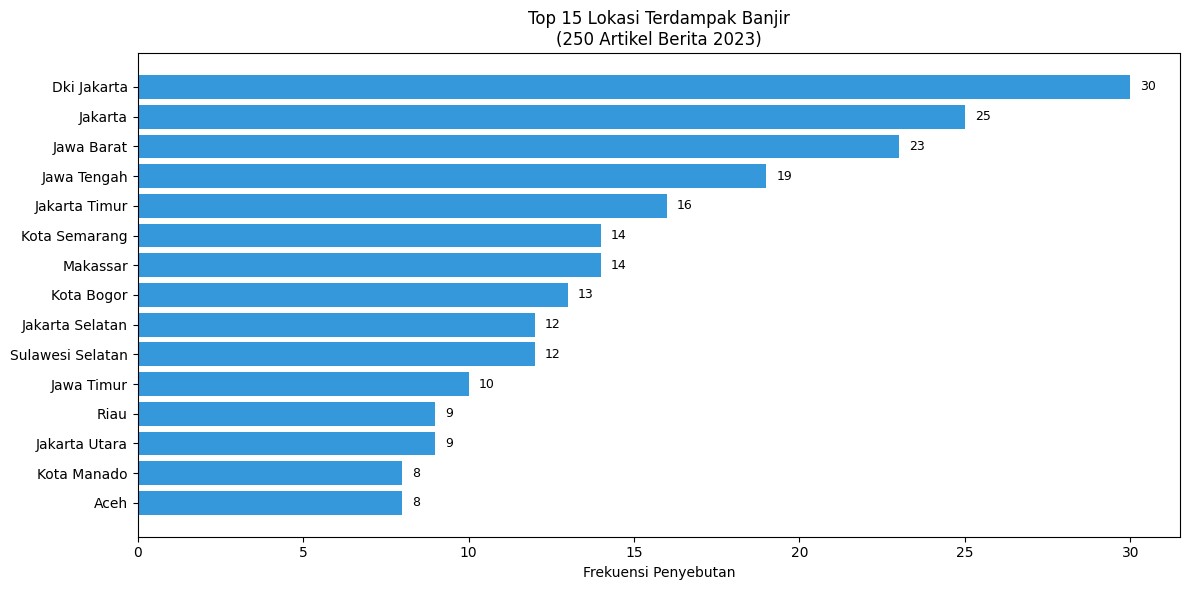

In [ ]:
from collections import Counter

# Ekstrak semua GPE dan LOC
locations = []
for entities in df['all_entities']:
    for ent in entities:
        if ent['entity_group'] in ['GPE', 'LOC']:
            locations.append(ent['word'].title())

# Top 15 lokasi
top_locations = Counter(locations).most_common(15)
loc_df = pd.DataFrame(top_locations, columns=['Lokasi', 'Count'])

plt.figure(figsize=(12, 6))
bars = plt.barh(loc_df['Lokasi'], loc_df['Count'], color='#3498db')
for bar, val in zip(bars, loc_df['Count']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.title('Top 15 Lokasi Terdampak Banjir\n(250 Artikel Berita 2023)')
plt.xlabel('Frekuensi Penyebutan')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

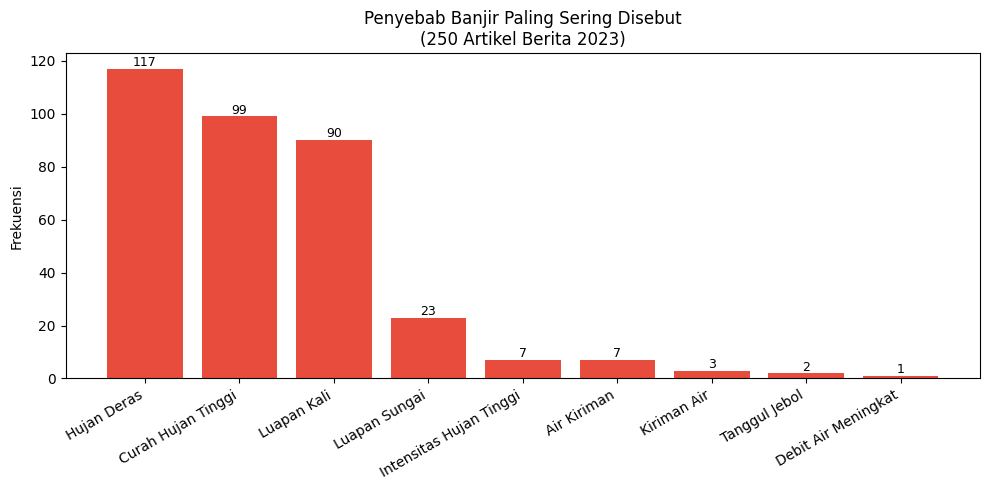

In [ ]:
# Ekstrak semua PENYEBAB
penyebab_list = []
for entities in df['all_entities']:
    for ent in entities:
        if ent['entity_group'] == 'PENYEBAB':
            penyebab_list.append(ent['word'].title())

# Top penyebab
top_penyebab = Counter(penyebab_list).most_common(10)
penyebab_df = pd.DataFrame(top_penyebab, columns=['Penyebab', 'Count'])

plt.figure(figsize=(10, 5))
bars = plt.bar(penyebab_df['Penyebab'], penyebab_df['Count'],
               color='#e74c3c')
for bar, val in zip(bars, penyebab_df['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=9)
plt.title('Penyebab Banjir Paling Sering Disebut\n(250 Artikel Berita 2023)')
plt.ylabel('Frekuensi')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

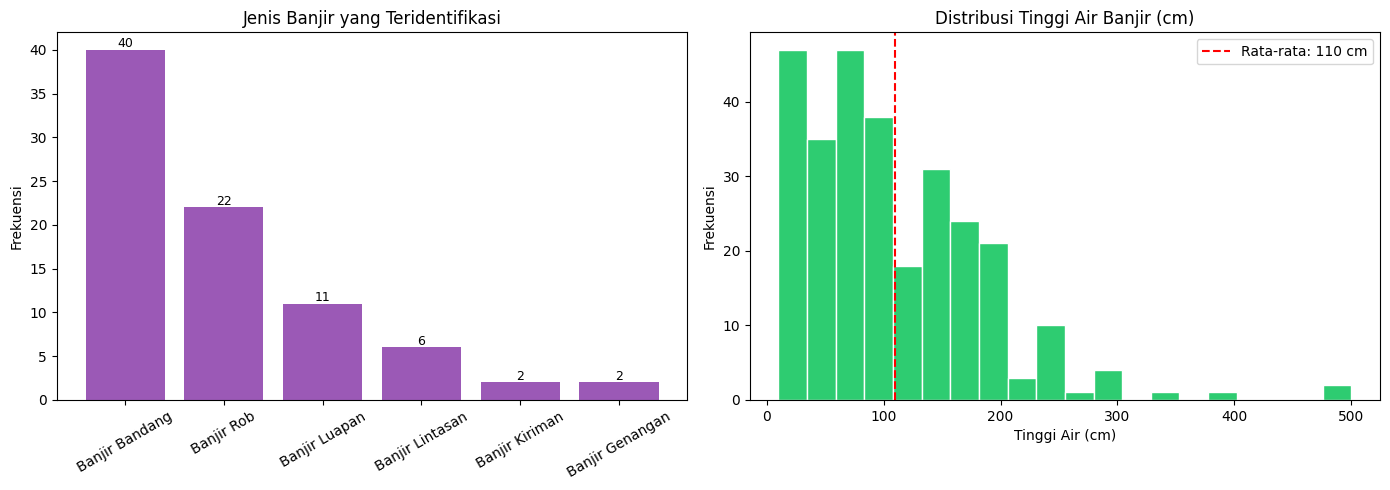

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Jenis Banjir
jenis_list = []
for entities in df['all_entities']:
    for ent in entities:
        if ent['entity_group'] == 'JENIS_BANJIR':
            jenis_list.append(ent['word'].title())

top_jenis = Counter(jenis_list).most_common()
jenis_df = pd.DataFrame(top_jenis, columns=['Jenis', 'Count'])

axes[0].bar(jenis_df['Jenis'], jenis_df['Count'], color='#9b59b6')
for i, (_, row) in enumerate(jenis_df.iterrows()):
    axes[0].text(i, row['Count'] + 0.3, str(row['Count']), ha='center', fontsize=9)
axes[0].set_title('Jenis Banjir yang Teridentifikasi')
axes[0].set_ylabel('Frekuensi')
axes[0].tick_params(axis='x', rotation=30)

# 2. Distribusi Tinggi Air
import re
tinggi_values = []
for entities in df['all_entities']:
    for ent in entities:
        if ent['entity_group'] == 'TINGGI_AIR':
            match = re.search(r'(\d+[\.,]?\d*)', ent['word'])
            unit = 'cm' if 'cm' in ent['word'] else 'meter'
            if match:
                val = float(match.group().replace(',', '.'))
                if unit == 'meter':
                    val = val * 100  # konversi ke cm
                if val <= 500:  # filter outlier
                    tinggi_values.append(val)

axes[1].hist(tinggi_values, bins=20, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribusi Tinggi Air Banjir (cm)')
axes[1].set_xlabel('Tinggi Air (cm)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(x=sum(tinggi_values)/len(tinggi_values),
                color='red', linestyle='--',
                label=f'Rata-rata: {sum(tinggi_values)/len(tinggi_values):.0f} cm')
axes[1].legend()

plt.tight_layout()
plt.show()

# 9. Insight Analysis

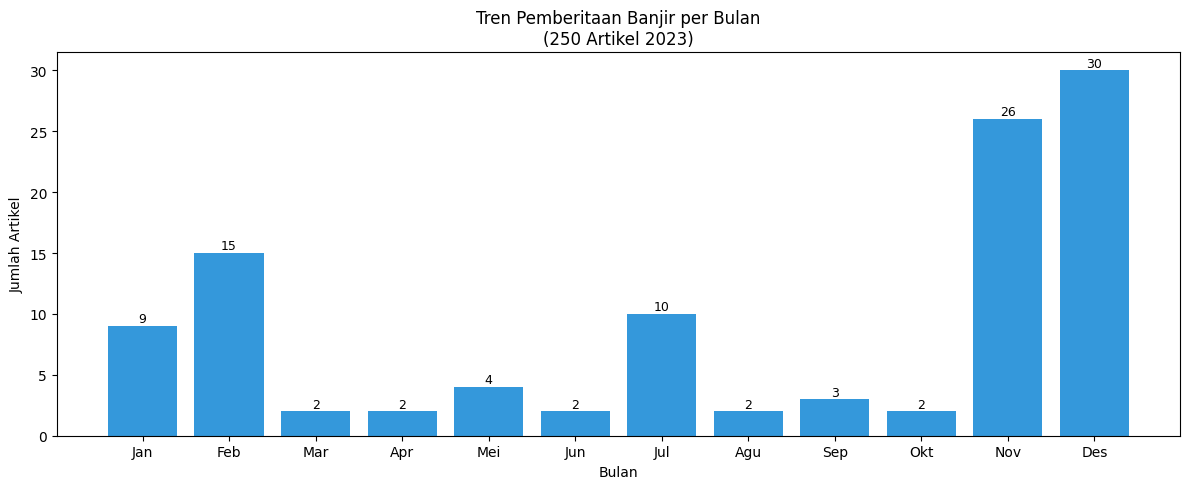


Insight:
- Pemberitaan banjir tertinggi pada bulan Des (30 artikel)
- Konsisten dengan musim hujan Indonesia (Nov-Mar)


In [ ]:
df['bulan'] = df['Date'].apply(parse_bulan)
bulan_count = df['bulan'].dropna().astype(int).value_counts().sort_index()

bulan_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

x_labels = [bulan_names[int(i)-1] for i in bulan_count.index]

plt.figure(figsize=(12, 5))
bars = plt.bar(x_labels, bulan_count.values, color='#3498db')
for bar, val in zip(bars, bulan_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontsize=9)

plt.title('Tren Pemberitaan Banjir per Bulan\n(250 Artikel 2023)')
plt.ylabel('Jumlah Artikel')
plt.xlabel('Bulan')
plt.tight_layout()
plt.show()

peak_idx = int(bulan_count.idxmax())
print(f"\nInsight:")
print(f"- Pemberitaan banjir tertinggi pada bulan {bulan_names[peak_idx-1]} ({bulan_count.max()} artikel)")
print(f"- Konsisten dengan musim hujan Indonesia (Nov-Mar)")

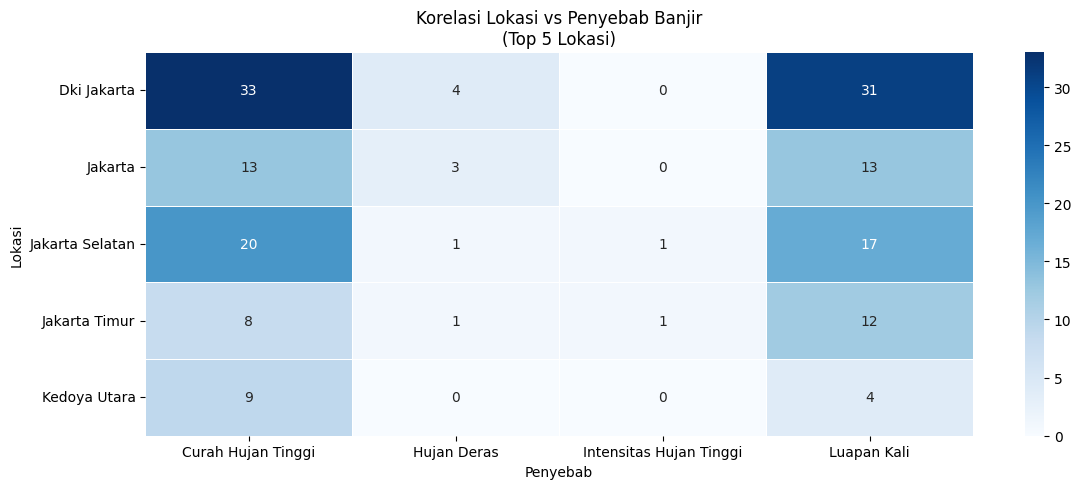

In [ ]:
# Untuk setiap artikel, ambil lokasi utama dan penyebabnya
rows = []
for i, row in df.iterrows():
    lokasi = None
    penyebab_list_article = []

    for ent in row['all_entities']:
        if ent['entity_group'] == 'GPE' and lokasi is None:
            lokasi = ent['word'].title()
        if ent['entity_group'] == 'PENYEBAB':
            penyebab_list_article.append(ent['word'].title())

    if lokasi and penyebab_list_article:
        for p in penyebab_list_article:
            rows.append({'Lokasi': lokasi, 'Penyebab': p})

insight_df = pd.DataFrame(rows)

# Top 5 lokasi
top5_lokasi = insight_df['Lokasi'].value_counts().head(5).index.tolist()
filtered = insight_df[insight_df['Lokasi'].isin(top5_lokasi)]

# Heatmap
pivot = filtered.groupby(['Lokasi', 'Penyebab']).size().unstack(fill_value=0)

import seaborn as sns
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Korelasi Lokasi vs Penyebab Banjir\n(Top 5 Lokasi)')
plt.ylabel('Lokasi')
plt.xlabel('Penyebab')
plt.tight_layout()
plt.show()

#10. Summary

In [ ]:
# Ringkasan statistik
total_entities = sum(len(e) for e in df['all_entities'])
total_locations = sum(1 for entities in df['all_entities']
                      for e in entities if e['entity_group'] in ['GPE', 'LOC'])
total_penyebab = sum(1 for entities in df['all_entities']
                     for e in entities if e['entity_group'] == 'PENYEBAB')
total_tinggi = len(tinggi_values)
avg_tinggi = sum(tinggi_values)/len(tinggi_values)

print("=" * 50)
print("RINGKASAN HASIL NER - BERITA BANJIR INDONESIA 2023")
print("=" * 50)
print(f"Total artikel dianalisis    : {len(df)}")
print(f"Total entitas diekstrak     : {total_entities}")
print(f"Total entitas lokasi        : {total_locations}")
print(f"Total penyebab teridentifikasi: {total_penyebab}")
print(f"Total data tinggi air       : {total_tinggi}")
print(f"Rata-rata tinggi air        : {avg_tinggi:.1f} cm")
print(f"Penyebab paling dominan     : {Counter(penyebab_list).most_common(1)[0][0]}")
print(f"Lokasi paling sering disebut: {Counter(locations).most_common(1)[0][0]}")
print(f"Bulan terbanyak berita      : {bulan_names[peak_idx-1]}")
print("=" * 50)

RINGKASAN HASIL NER - BERITA BANJIR INDONESIA 2023
Total artikel dianalisis    : 250
Total entitas diekstrak     : 4063
Total entitas lokasi        : 1388
Total penyebab teridentifikasi: 349
Total data tinggi air       : 283
Rata-rata tinggi air        : 109.9 cm
Penyebab paling dominan     : Hujan Deras
Lokasi paling sering disebut: Dki Jakarta
Bulan terbanyak berita      : Des


# 11. Evaluation

In [ ]:
# Evaluasi kualitatif — spot check 5 artikel random
import random
random.seed(42)
sample_idx = random.sample(range(len(df)), 5)

print("=== EVALUASI KUALITATIF — SPOT CHECK ===\n")

for idx in sample_idx:
    entities = df['all_entities'][idx]
    grouped = {}
    for ent in entities:
        etype = ent['entity_group']
        if etype not in grouped:
            grouped[etype] = []
        if ent['word'] not in grouped[etype]:
            grouped[etype].append(ent['word'])

    print(f"Artikel: {df['Headline'][idx][:70]}...")
    print(f"Tanggal: {df['Date'][idx]}")
    print("Entitas yang diekstrak:")
    for etype, words in grouped.items():
        print(f"  {etype:12}: {', '.join(words[:4])}")

    # Hitung entitas custom
    custom_count = sum(1 for e in entities
                      if e['entity_group'] in ['TINGGI_AIR', 'JENIS_BANJIR', 'KORBAN', 'PENYEBAB'])
    indobert_count_art = sum(1 for e in entities
                             if e['entity_group'] not in ['TINGGI_AIR', 'JENIS_BANJIR', 'KORBAN', 'PENYEBAB'])

    print(f"  → IndoBERT: {indobert_count_art} entitas | Rule-Based: {custom_count} entitas")
    print()

=== EVALUASI KUALITATIF — SPOT CHECK ===

Artikel: Makassar Dikepung Banjir, Ketinggian Hampir Merata Capai 1 Meter...
Tanggal:  13 Feb 2023 11:28
Entitas yang diekstrak:
  GPE         : kota makassar, sulawesi selatan, makassar
  QTY         : 1 meter, 1, 5 meter
  CRD         : dua
  NOR         : walikota makassar
  PER         : moh ramdhan pomanto, danny, ba
  DAT         : senin ( 13 / 2 )
  TINGGI_AIR  : 1 meter, 1,5 meter
  PENYEBAB    : hujan deras
  → IndoBERT: 11 entitas | Rule-Based: 3 entitas

Artikel: Hujan Deras di Bogor, Banjir Setinggi 1 Meter Rendam Sejumlah Rumah Wa...
Tanggal: 30 Nov 2023 19:43
Entitas yang diekstrak:
  GPE         : kota bogor, kelurahan tanahbaru, kecamatan bogor utara, kelurahan cibuluh
  QTY         : 1 meter
  LOC         : kampung ciheuleut rt 06 rw 06
  PER         : purwadi
  DAT         : kamis ( 30 / 11 / 2023 )
  TIM         : 18. 30 wib
  TINGGI_AIR  : 1 meter
  JENIS_BANJIR: banjir lintasan
  PENYEBAB    : hujan deras
  → IndoBERT: 12 e